In [39]:
pip install xgboost

**NYC Airbnb Room Type Classification**

**Dataset**: New York City Airbnb Open Data (Kaggle)

**Goal:** Predict the room_type of an Airbnb listing (Entire home/apt, Private room, or Shared room) using listing attributes such as price, location, availability, and review activity.

**What this notebook covers (the full ML lifecycle):**



1. Problem framing & data loading
2. Exploratory Data Analysis (EDA) — univariate, bivariate, skewness, outliers


1. Data cleaning & feature engineering


1.   Train / test split




1.   Preprocessing with ColumnTransformer + Pipeline

1.   Baseline model

1.   Multiple candidate algorithms (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting)

1.   Model comparison (cross-validation)

1.   Hyperparameter tuning of the best model
2.   Final evaluation on the untouched test set


2.   Feature importance


2.   Saving the final pipeline (model artifact)


2.   Conclusion & next steps











**Import Libraries**

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,roc_curve,classification_report
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')

**Load the Dataset**

In [41]:
df=pd.read_csv("/content/AB_NYC_2019.csv")

In [42]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [43]:
df.shape

(48895, 16)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [45]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


**Exploratory Data Analysis (EDA)**

We explore the data in the standard order every ML engineer follows:



*   Missing values
*   Univariate analysis (one variable at a time — distributions, skewness)


*   Bivariate analysis (relationship between features and the target)
*   Correlation between numeric features



*   Outlier inspection








**Missing Values**

In [46]:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


 Target Variable — room_type

In [47]:
df["room_type"].value_counts()

,count
room_type,
Entire home/apt,25409
Private room,22326
Shared room,1160


<Axes: xlabel='room_type', ylabel='count'>

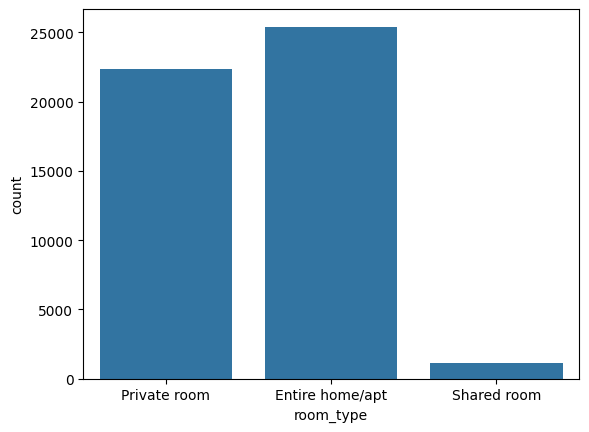

In [48]:
sns.countplot(x="room_type",data=df)

The classes are imbalanced -> Shared Room is a Small Minority.

**Univariate Analysis** — **Numeric Features**

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>]], dtype=object)

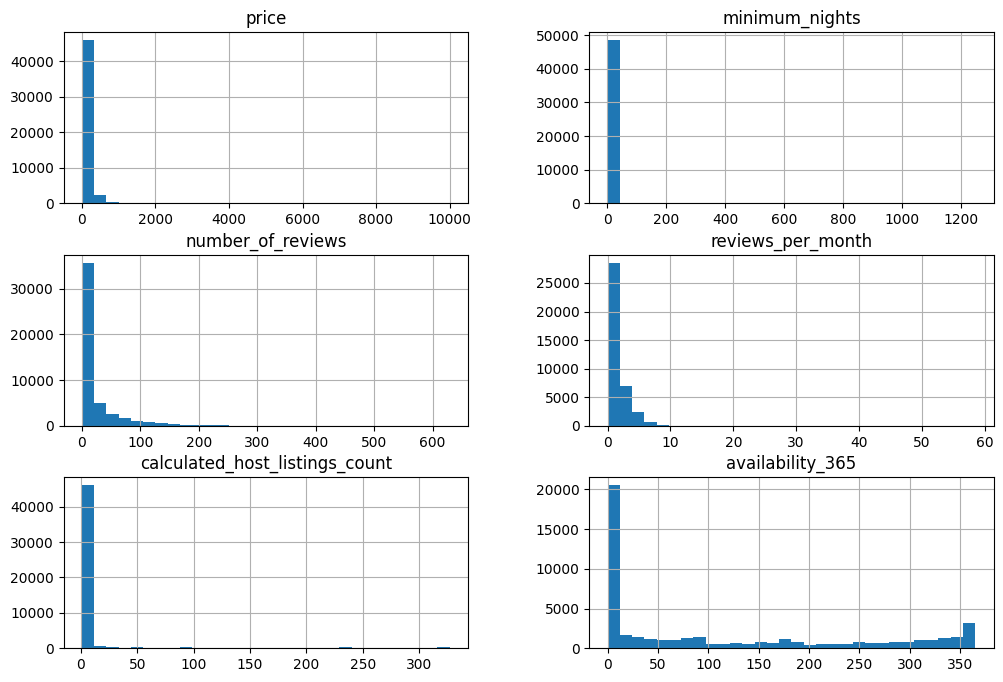

In [49]:
numerical_cols = ["price", "minimum_nights", "number_of_reviews",
                 "reviews_per_month", "calculated_host_listings_count",
                 "availability_365"]

df[numerical_cols].hist(bins=30, figsize=(12, 8))


**Univariate Analysis** — **Categorical Features**

<Axes: xlabel='neighbourhood_group', ylabel='count'>

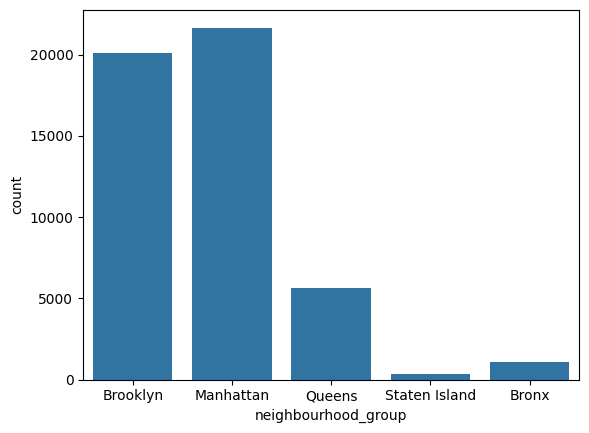

In [50]:
sns.countplot(data=df, x='neighbourhood_group')

**Bivariate Analysis** — **Features vs Target**

<Axes: xlabel='room_type', ylabel='price'>

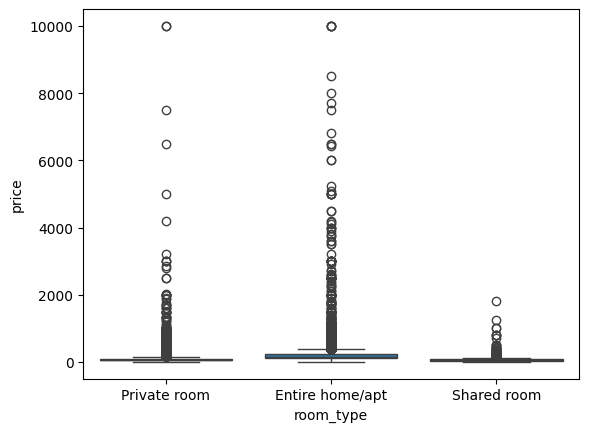

In [51]:
sns.boxplot(x='room_type', y='price', data=df)

**Correlation Between Numeric Features**

<Axes: >

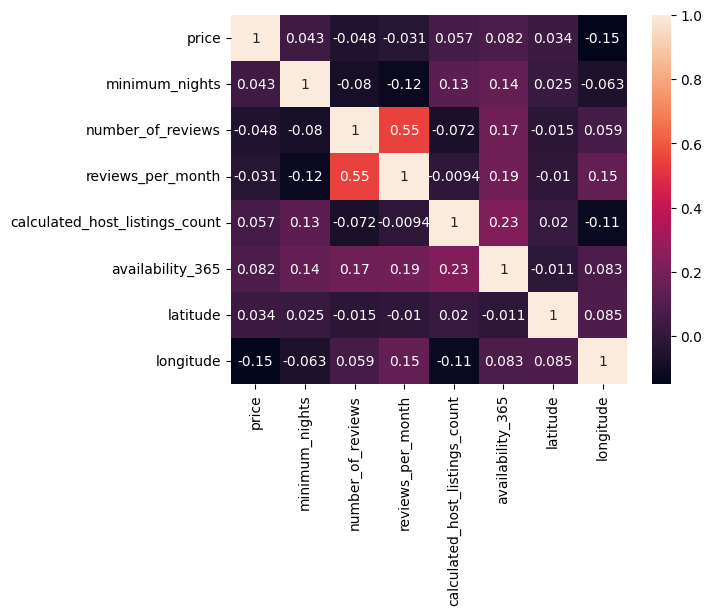

In [52]:
corr = df[numerical_cols + ['latitude', 'longitude']].corr()
sns.heatmap(corr,annot=True
            )

**Geographic Distribution** (**Bonus Visual**)

<Axes: xlabel='longitude', ylabel='latitude'>

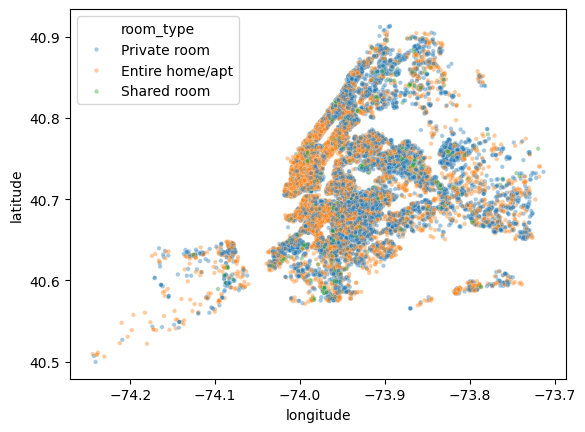

In [53]:
sns.scatterplot(x='longitude', y='latitude',data=df, hue='room_type', alpha=0.4, s=10)

**Data Cleaning & Feature Engineering**



1.  Drop columns that are pure identifiers or free text and carry no generalizable signal for a tabular model (id, name, host_id, host_name, last_review).

1.   Fill missing reviews_per_month with 0 (no reviews yet).
2.   Cap extreme outliers in price and minimum_nights using percentile clipping, so a handful of data-entry errors (e.g. $10,000/night, 1,250 minimum nights) don't distort the model.


2.   Separate features (X) from the target (y).



In [54]:
#1. Drop Colunmns that dont help us.
df_clean = df.drop(columns=['id', 'name', 'host_id', 'host_name', 'last_review'])

#2. No reviews yet -> 0 reviews per month, not missing
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)

In [55]:
#3. Cap Extreme outliers instead of deleting rows.

price_cap  = df_clean['price'].quantile(0.99)
nights_cap = df_clean['minimum_nights'].quantile(0.99)

df_clean['price'] = df_clean['price'].clip(upper=price_cap)
df_clean['minimum_nights'] = df_clean['minimum_nights'].clip(upper=nights_cap)


# df_clean = df_clean[df_clean['price'] < price_cap]
# df_clean = df_clean[df_clean['minimum_nights'] < nights_cap]

In [56]:
df.shape

(48895, 16)

<Axes: xlabel='room_type', ylabel='price'>

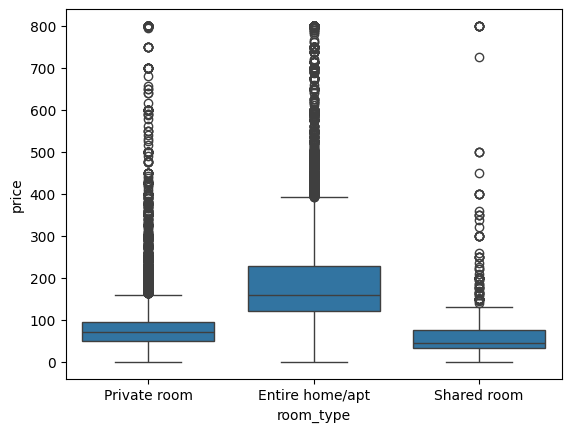

In [57]:
sns.boxplot(x='room_type', y='price', data=df_clean)

In [58]:
X = df_clean.drop(columns=['room_type'])
y = df_clean['room_type']

**Train / Test Split**

We hold out 20% of the data as a test set that is never touched during model selection or tuning — it is only used once, at the very end, to report the final, honest performance. stratify=y keeps the same class proportions in both splits, which matters because the target is imbalanced.

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)

**Preprocessing: ColumnTransformer + Pipeline**

Production ML code should never manually transform train/test data with separate lines — it's error-prone and leaks information. Instead we build a single, reusable ColumnTransformer:



*   **Numeric features** → median imputation + standard scaling
*   **Categorical features** → most-frequent imputation + one-hot encoding

This transformer will be the first step of every model pipeline below, so preprocessing is learned only on training data and applied consistently everywhere (no data leakage).



In [60]:
numerical_cols = ["latitude","longitude","price", "minimum_nights", "number_of_reviews",
                 "reviews_per_month", "calculated_host_listings_count",
                 "availability_365"]

categorical_cols = ['neighbourhood_group', 'neighbourhood']

#1. Pipeline -> for Numeric Columns
numeric_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy="median")),
    ('scale', StandardScaler())
])


#2. Pipeline -> for Categorical Columns
categorical_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy="most_frequent")),
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ("numerical", numeric_pipeline, numerical_cols),
    ("categorical", categorical_pipeline, categorical_cols )
])

preprocessor

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['latitude', 'longitude', 'price',
                                  'minimum_nights', 'number_of_reviews',
                                  'reviews_per_month',
                                  'calculated_host_listings_count',
                                  'availability_365']),
                                ('categorical',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encode',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['neighbourhood_group', 'neighbourhood'])])

In [61]:
df_clean['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

**Trying Multiple Algorithms**

We now compare several models, each wrapped in its own pipeline with the same preprocessor. We evaluate each with 3-fold stratified cross-validation on the training set (never touching the test set yet), so the comparison is fair and robust.

**Models tried:**


1.   **Logistic Regression** — simple, interpretable linear baseline
2.   **Decision Tree** — a single non-linear model, prone to overfitting


1.   **Random Fores**t — an ensemble of trees, usually a strong general-purpose model
2.   **Gradient Boosting** — sequential ensemble, often the most accurate of the classics







**SMOTE (Synthetic Minority Oversampling).**

**for class IMbalance**



1.   High chances of Overfitting.
2.   Data Leakage



**Logistic Regression pipeline**

In [62]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
#pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])
# 5-FOLD CROSS VALIDATION
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
cv_scores = cross_val_score(
    lr_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring='f1_macro'
)
lr_cv_f1 = cv_scores.mean()
#TRAIN MODEL
lr_pipeline.fit(X_train, y_train)
#PREDICTION
lr_pred = lr_pipeline.predict(X_test)


In [63]:
#EVALUATION METRICS
lr_accuracy = accuracy_score(y_test, lr_pred)

lr_precision = precision_score(
    y_test,
    lr_pred,
    average='macro',
    zero_division=0
)
lr_recall = recall_score(
    y_test,
    lr_pred,
    average='macro',
    zero_division=0
)
lr_f1_macro = f1_score(
    y_test,
    lr_pred,
    average='macro',
    zero_division=0
)
lr_f1_weighted = f1_score(
    y_test,
    lr_pred,
    average='weighted',
    zero_division=0
)
#print result
print("=" * 60)
print("LOGISTIC REGRESSION - EVALUATION")
print("=" * 60)

print("5-Fold CV F1 Macro:", lr_cv_f1)
print("Test Accuracy:", lr_accuracy)
print("Test Precision Macro:", lr_precision)
print("Test Recall Macro:", lr_recall)
print("Test F1 Macro:", lr_f1_macro)
print("Test F1 Weighted:", lr_f1_weighted)

LOGISTIC REGRESSION - EVALUATION
5-Fold CV F1 Macro: 0.522777549057788
Test Accuracy: 0.6689390183440753
Test Precision Macro: 0.5557471076979491
Test Recall Macro: 0.6666717191135341
Test F1 Macro: 0.533591663782437
Test F1 Weighted: 0.7125073864076765



Classification Report:
                 precision    recall  f1-score   support

Entire home/apt       0.87      0.73      0.79      8385
   Private room       0.71      0.60      0.65      7368
    Shared room       0.09      0.67      0.16       383

       accuracy                           0.67     16136
      macro avg       0.56      0.67      0.53     16136
   weighted avg       0.78      0.67      0.71     16136


Confusion Matrix:
[[6142 1681  562]
 [ 924 4395 2049]
 [  32   94  257]]


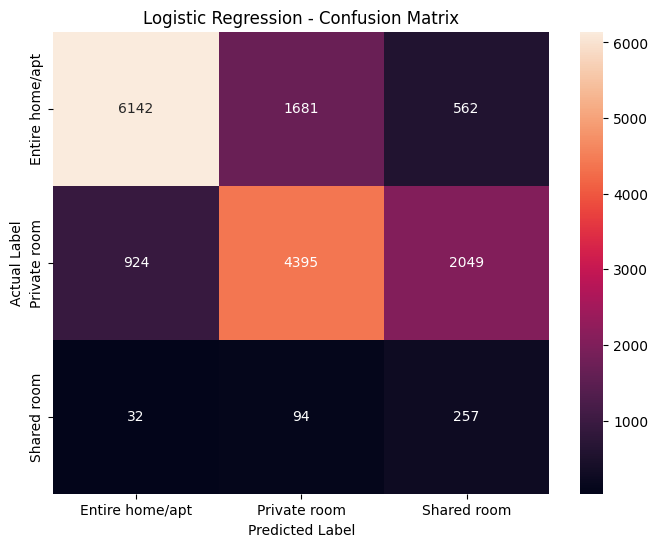

In [64]:
#CLASSIFICATION REPORT
print("\nClassification Report:")
print(classification_report(
    y_test,
    lr_pred,
    zero_division=0
))
#CONFUSION MATRIX
cm = confusion_matrix(y_test, lr_pred)
print("\nConfusion Matrix:")
print(cm)
#CONFUSION MATRIX PLOT
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=lr_pipeline.classes_,
    yticklabels=lr_pipeline.classes_
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

**Decision** **Tree** **with** **default** **training**

In [65]:
# DECISION TREE PIPELINE
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42
    ))
])
# 5-FOLD CROSS VALIDATION
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
cv_scores = cross_val_score(
    dt_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring='f1_macro'
)
dt_cv_f1 = cv_scores.mean()
# TRAIN MODEL
dt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['latitude', 'longitude',
                                                   'price', 'minimum_nights',
                                                   'number_of_reviews',
                                                   'reviews_per_month',
                                                   'calculated_host_listings_count',
                                                   'availability_365']),
                                                 ('categorical',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['neighbourhood_group',
                                                   'neighbourhood'])])),
                ('classifier',
                 DecisionTreeClassifier(class_weight='balanced',
                                        random_state=42))])

In [66]:
# PREDICTION
dt_pred = dt_pipeline.predict(X_test)

In [67]:
# EVALUATION METRICS
dt_accuracy = accuracy_score(y_test, dt_pred)

dt_precision = precision_score(
    y_test,
    dt_pred,
    average='macro',
    zero_division=0
)
dt_recall = recall_score(
    y_test,
    dt_pred,
    average='macro',
    zero_division=0
)
dt_f1_macro = f1_score(
    y_test,
    dt_pred,
    average='macro',
    zero_division=0
)
dt_f1_weighted = f1_score(
    y_test,
    dt_pred,
    average='weighted',
    zero_division=0
)

In [68]:
# PRINT RESULTS
print("=" * 60)
print("DECISION TREE - EVALUATION")
print("=" * 60)

print("5-Fold CV F1 Macro:", dt_cv_f1)
print("Test Accuracy:", dt_accuracy)
print("Test Precision Macro:", dt_precision)
print("Test Recall Macro:", dt_recall)
print("Test F1 Macro:", dt_f1_macro)
print("Test F1 Weighted:", dt_f1_weighted)

DECISION TREE - EVALUATION
5-Fold CV F1 Macro: 0.6541652445827164
Test Accuracy: 0.7869360436291523
Test Precision Macro: 0.6635207010677227
Test Recall Macro: 0.6568287285519128
Test F1 Macro: 0.6600277465380261
Test F1 Weighted: 0.786815474312815



Classification Report:
                 precision    recall  f1-score   support

Entire home/apt       0.82      0.81      0.82      8385
   Private room       0.77      0.78      0.77      7368
    Shared room       0.40      0.38      0.39       383

       accuracy                           0.79     16136
      macro avg       0.66      0.66      0.66     16136
   weighted avg       0.79      0.79      0.79     16136



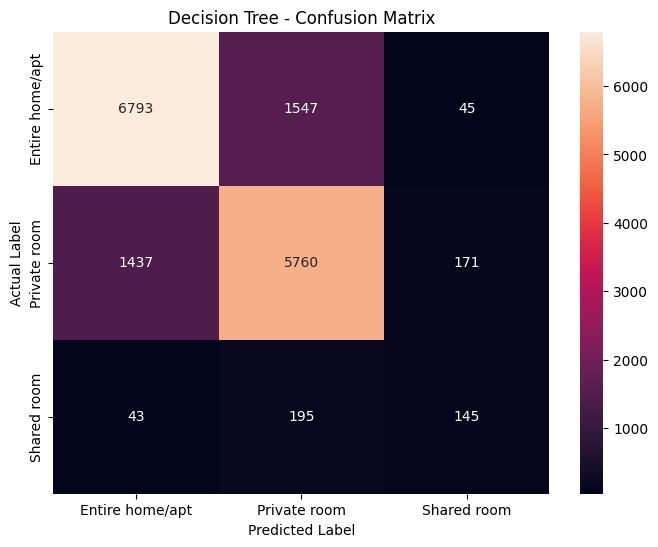

In [69]:
# CLASSIFICATION REPORT
dt_cm = confusion_matrix(y_test, dt_pred)
print("\nClassification Report:")
print(classification_report(
    y_test,
    dt_pred,
    zero_division=0
))
# CONFUSION MATRIX
plt.figure(figsize=(8, 6))
sns.heatmap(
    dt_cm,
    annot=True,
    fmt='d',
    xticklabels=dt_pipeline.classes_,
    yticklabels=dt_pipeline.classes_
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Decision Tree - Confusion Matrix")
plt.show()

**Hyper parameter tunnig for decision tree using gridseach CV**

In [70]:
from sklearn.model_selection import GridSearchCV
#PARAMETER GRID
param_grid = {
    'classifier__criterion': ['gini'],
    'classifier__max_depth': [22,23,32,34,36],
    'classifier__min_samples_split': [3,3.25,3.5,3.75],
    'classifier__min_samples_leaf': [1]
}
#5-FOLD STRATIFIED CROSS VALIDATION
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
#GRID SEARCH
dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
#TRAIN GRID SEARCH
dt_grid.fit(X_train, y_train)
#BEST PARAMETERS
print("Best Parameters:")
print(dt_grid.best_params_)

print("\nBest CV F1 Macro:")
print(dt_grid.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters:
{'classifier__criterion': 'gini', 'classifier__max_depth': 22, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 3}

Best CV F1 Macro:
0.657618068842822


In [71]:
# FINAL PREDICTION
dt_pred_grid = dt_grid.predict(X_test)


TUNED DECISION TREE - EVALUATION
5-Fold CV F1 Macro: 0.657618068842822
Test Accuracy: 0.7920178482895389
Test Precision Macro: 0.6543890641660116
Test Recall Macro: 0.669257694173215
Test F1 Macro: 0.6612765500708688
Test F1 Weighted: 0.7928072412723869

Classification Report:
                 precision    recall  f1-score   support

Entire home/apt       0.83      0.82      0.82      8385
   Private room       0.78      0.78      0.78      7368
    Shared room       0.36      0.41      0.38       383

       accuracy                           0.79     16136
      macro avg       0.65      0.67      0.66     16136
   weighted avg       0.79      0.79      0.79     16136


Confusion Matrix:
[[6858 1464   63]
 [1385 5766  217]
 [  41  186  156]]


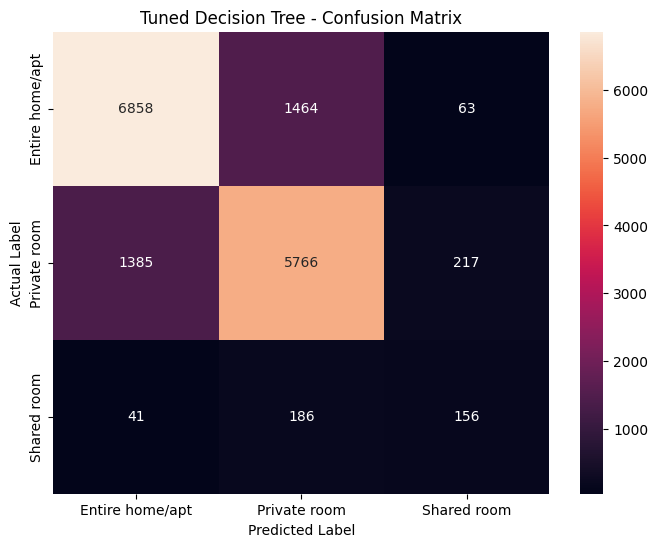

In [72]:
# EVALUATION METRICS
dt_accuracy = accuracy_score(y_test, dt_pred_grid)
dt_precision = precision_score(
    y_test,
    dt_pred_grid,
    average='macro',
    zero_division=0
)
dt_recall = recall_score(
    y_test,
    dt_pred_grid,
    average='macro',
    zero_division=0
)
dt_f1_macro = f1_score(
    y_test,
    dt_pred_grid,
    average='macro',
    zero_division=0
)
dt_f1_weighted = f1_score(
    y_test,
    dt_pred_grid,
    average='weighted',
    zero_division=0
)
#FINAL RESULTS
print("=" * 60)
print("TUNED DECISION TREE - EVALUATION")
print("=" * 60)
print("5-Fold CV F1 Macro:", dt_grid.best_score_)
print("Test Accuracy:", dt_accuracy)
print("Test Precision Macro:", dt_precision)
print("Test Recall Macro:", dt_recall)
print("Test F1 Macro:", dt_f1_macro)
print("Test F1 Weighted:", dt_f1_weighted)
# CLASSIFICATION REPORT
print("\nClassification Report:")
print(classification_report(
    y_test,
    dt_pred_grid,
    zero_division=0
))
# CONFUSION MATRIX
dt_cm = confusion_matrix(y_test, dt_pred_grid)
print("\nConfusion Matrix:")
print(dt_cm)
# CONFUSION MATRIX PLOT
plt.figure(figsize=(8, 6))
sns.heatmap(
    dt_cm,
    annot=True,
    fmt='d',
    xticklabels=dt_grid.classes_,
    yticklabels=dt_grid.classes_
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Tuned Decision Tree - Confusion Matrix")
plt.show()

**Random forest defualt parameter**

In [73]:
# PIPELINE
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])
# 5-FOLD CROSS VALIDATION
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
cv_scores = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)
rf_cv_f1 = cv_scores.mean()
# TRAIN MODEL
rf_pipeline.fit(X_train, y_train)
# PREDICTION
rf_pred = rf_pipeline.predict(X_test)

RANDOM FOREST - EVALUATION
5-Fold CV F1 Macro: 0.7216418001855937
Test Accuracy: 0.8554784333168072
Test Precision Macro: 0.8788237454062285
Test Recall Macro: 0.6696345517860197
Test F1 Macro: 0.7142356911928808
Test F1 Weighted: 0.8517742810644379

Confusion Matrix:
[[7413  972    0]
 [1073 6287    8]
 [  35  244  104]]


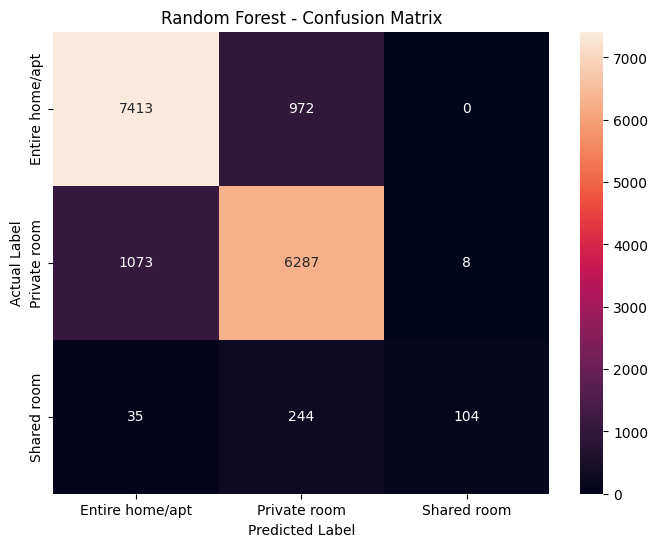

In [74]:
# EVALUATION METRICS
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(
    y_test,
    rf_pred,
    average='macro',
    zero_division=0
)
rf_recall = recall_score(
    y_test,
    rf_pred,
    average='macro',
    zero_division=0
)
rf_f1_macro = f1_score(
    y_test,
    rf_pred,
    average='macro',
    zero_division=0
)
rf_f1_weighted = f1_score(
    y_test,
    rf_pred,
    average='weighted',
    zero_division=0
)
# PRINT RESULTS
print("=" * 60)
print("RANDOM FOREST - EVALUATION")
print("=" * 60)
print("5-Fold CV F1 Macro:", rf_cv_f1)
print("Test Accuracy:", rf_accuracy)
print("Test Precision Macro:", rf_precision)
print("Test Recall Macro:", rf_recall)
print("Test F1 Macro:", rf_f1_macro)
print("Test F1 Weighted:", rf_f1_weighted)
# CONFUSION MATRIX
rf_cm = confusion_matrix(y_test, rf_pred)
print("\nConfusion Matrix:")
print(rf_cm)
# CONFUSION MATRIX PLOT
plt.figure(figsize=(8, 6))
sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    xticklabels=rf_pipeline.classes_,
    yticklabels=rf_pipeline.classes_
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Random Forest - Confusion Matrix")
plt.show()

**Hyperparameter Tunnig for Rndomforest using GridsearchCV**

In [75]:
# PARAMETER GRID
param_grid = {
    'classifier__n_estimators': [300],
    'classifier__max_depth': [None],
    'classifier__min_samples_split': [5],
    'classifier__min_samples_leaf': [1],
    'classifier__max_features': ['sqrt'],
}
# 5-FOLD STRATIFIED CV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
# GRID SEARCH
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=3,
    refit=True
)
# TRAIN
rf_grid.fit(X_train, y_train)
# BEST PARAMETERS
print("Best Parameters:")
print(rf_grid.best_params_)

print("\nBest CV Macro-F1:")
print(rf_grid.best_score_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best Parameters:
{'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 300}

Best CV Macro-F1:
0.7266719242599977


In [76]:
# RANDOM FOREST - TUNED EVALUATION
# Prediction
rf_pred_grid = rf_grid.predict(X_test)
# Metrics
rf_accuracy = accuracy_score(y_test, rf_pred_grid)
rf_precision = precision_score(
    y_test,
    rf_pred_grid,
    average='macro',
    zero_division=0
)
rf_recall = recall_score(
    y_test,
    rf_pred_grid,
    average='macro',
    zero_division=0
)
rf_f1_macro = f1_score(
    y_test,
    rf_pred_grid,
    average='macro',
    zero_division=0
)
rf_f1_weighted = f1_score(
    y_test,
    rf_pred_grid,
    average='weighted',
    zero_division=0
)
# FINAL RESULTS
print("=" * 60)
print("TUNED RANDOM FOREST - EVALUATION")
print("=" * 60)
print("5-Fold CV F1 Macro:", rf_grid.best_score_)
print("Test Accuracy:", rf_accuracy)
print("Test Precision Macro:", rf_precision)
print("Test Recall Macro:", rf_recall)
print("Test F1 Macro:", rf_f1_macro)
print("Test F1 Weighted:", rf_f1_weighted)

TUNED RANDOM FOREST - EVALUATION
5-Fold CV F1 Macro: 0.7266719242599977
Test Accuracy: 0.8575855230540407
Test Precision Macro: 0.8779971569792672
Test Recall Macro: 0.6828171552514771
Test F1 Macro: 0.7293135582048498
Test F1 Weighted: 0.8544578564041262



Classification Report:
                 precision    recall  f1-score   support

Entire home/apt       0.87      0.88      0.88      8385
   Private room       0.84      0.86      0.85      7368
    Shared room       0.92      0.31      0.46       383

       accuracy                           0.86     16136
      macro avg       0.88      0.68      0.73     16136
   weighted avg       0.86      0.86      0.85     16136


Confusion Matrix:
[[7396  989    0]
 [1034 6324   10]
 [  36  229  118]]


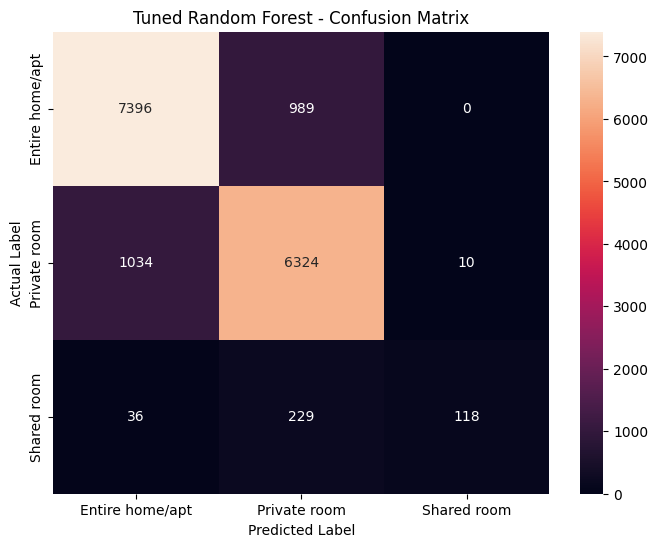

In [77]:
# CLASSIFICATION REPORT
print("\nClassification Report:")

print(classification_report(
    y_test,
    rf_pred_grid,
    zero_division=0
))
# CONFUSION MATRIX
rf_cm = confusion_matrix(y_test, rf_pred_grid)
print("\nConfusion Matrix:")
print(rf_cm)
# CONFUSION MATRIX PLOT
plt.figure(figsize=(8, 6))
sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    xticklabels=rf_grid.classes_,
    yticklabels=rf_grid.classes_
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Tuned Random Forest - Confusion Matrix")
plt.show()

**train model with XGboost with default**

In [78]:
from sklearn.utils.class_weight import compute_sample_weight

In [79]:
# Class mapping
class_mapping = {
    'Entire home/apt': 0,
    'Private room': 1,
    'Shared room': 2
}

y_train_xgb = y_train.map(class_mapping)
y_test_xgb = y_test.map(class_mapping)

# Balanced sample weights
xgb_sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train_xgb
)

print("Training class distribution:")
print(y_train_xgb.value_counts())

print("\nTest class distribution:")
print(y_test_xgb.value_counts())

Training class distribution:
room_type
0    17024
1    14958
2      777
Name: count, dtype: int64

Test class distribution:
room_type
0    8385
1    7368
2     383
Name: count, dtype: int64


In [80]:
# DEFAULT XGBOOST PIPELINE
xgb_default_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        objective='multi:softmax',
        num_class=3,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    ))
])

In [81]:
# 5-FOLD STRATIFIED CROSS VALIDATION
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgb_default_cv_scores = cross_val_score(
    xgb_default_pipeline,
    X_train,
    y_train_xgb,
    cv=cv,
    scoring='f1_macro',
    params={
        'classifier__sample_weight': xgb_sample_weights
    }
)

xgb_default_cv_f1 = xgb_default_cv_scores.mean()

print("\n5-Fold CV F1 Macro Scores:")
print(xgb_default_cv_scores)

print("\nMean CV F1 Macro:")
print(xgb_default_cv_f1)


5-Fold CV F1 Macro Scores:
[0.70332442 0.69711253 0.73396078 0.72818525 0.70672411]

Mean CV F1 Macro:
0.7138614179257851


In [82]:
# TRAIN DEFAULT XGBOOST
xgb_default_pipeline.fit(
    X_train,
    y_train_xgb,
    classifier__sample_weight=xgb_sample_weights
)
#prediction
xgb_default_pred = xgb_default_pipeline.predict(X_test)

In [83]:
# EVALUATION
xgb_default_accuracy = accuracy_score(
    y_test_xgb,
    xgb_default_pred
)

xgb_default_precision = precision_score(
    y_test_xgb,
    xgb_default_pred,
    average='macro',
    zero_division=0
)

xgb_default_recall = recall_score(
    y_test_xgb,
    xgb_default_pred,
    average='macro',
    zero_division=0
)

xgb_default_f1_macro = f1_score(
    y_test_xgb,
    xgb_default_pred,
    average='macro',
    zero_division=0
)

xgb_default_f1_weighted = f1_score(
    y_test_xgb,
    xgb_default_pred,
    average='weighted',
    zero_division=0
)


# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DEFAULT XGBOOST - FINAL EVALUATION")
print("=" * 70)

print("5-Fold CV F1 Macro:", xgb_default_cv_f1)
print("Test Accuracy:", xgb_default_accuracy)
print("Test Precision Macro:", xgb_default_precision)
print("Test Recall Macro:", xgb_default_recall)
print("Test F1 Macro:", xgb_default_f1_macro)
print("Test F1 Weighted:", xgb_default_f1_weighted)

print("\nClassification Report:")
print(
    classification_report(
        y_test_xgb,
        xgb_default_pred,
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_xgb,
        xgb_default_pred
    )
)


DEFAULT XGBOOST - FINAL EVALUATION
5-Fold CV F1 Macro: 0.7138614179257851
Test Accuracy: 0.8511403073872087
Test Precision Macro: 0.7004208093894865
Test Recall Macro: 0.752848835717459
Test F1 Macro: 0.7205710333159575
Test F1 Weighted: 0.8533612907909988

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.89      0.88      8385
           1       0.86      0.82      0.84      7368
           2       0.37      0.55      0.44       383

    accuracy                           0.85     16136
   macro avg       0.70      0.75      0.72     16136
weighted avg       0.86      0.85      0.85     16136


Confusion Matrix:
[[7459  876   50]
 [ 989 6066  313]
 [  31  143  209]]


**tuning XGBoost hyperparameters can be done using gridsearchCV**

In [85]:
X_xgb_train, X_xgb_val, y_xgb_train, y_xgb_val = train_test_split(
    X_train,
    y_train_xgb,
    test_size=0.20,
    random_state=42,
    stratify=y_train_xgb
)

xgb_sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_xgb_train)

In [86]:
xgb_tuned_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        objective='multi:softmax',
        num_class=3,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    ))
])

In [87]:
param_grid = {
    "classifier__n_estimators": [400],
    "classifier__max_depth": [7],
    "classifier__learning_rate": [0.1],
    "classifier__min_child_weight": [1],
    "classifier__subsample": [0.8],
    "classifier__colsample_bytree": [0.8],
    "classifier__gamma": [0.1]
}

In [88]:
from sklearn.model_selection import GridSearchCV, PredefinedSplit


# Combine training and validation data
X_grid = pd.concat([X_xgb_train, X_xgb_val])
y_grid = pd.concat([y_xgb_train, y_xgb_val])

# -1 = training data
#  0 = validation data
test_fold = np.concatenate([
    np.full(len(X_xgb_train), -1),
    np.zeros(len(X_xgb_val))
])

ps = PredefinedSplit(test_fold=test_fold)

# Combine sample weights
grid_sample_weights = np.concatenate([
    xgb_sample_weights,
    np.zeros(len(X_xgb_val))
])

In [89]:
xgb_grid = GridSearchCV(
    estimator=xgb_tuned_pipeline,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=ps,
    n_jobs=1,
    verbose=3,
    refit=True
)

xgb_grid.fit(
    X_grid,
    y_grid,
    classifier__sample_weight=grid_sample_weights
)

print("Best parameters found: ", xgb_grid.best_params_)
print("Best cross-validation score: ", xgb_grid.best_score_)

xgb_pred_grid = xgb_grid.predict(X_test)

Fitting 1 folds for each of 1 candidates, totalling 1 fits
[CV 1/1] END classifier__colsample_bytree=0.8, classifier__gamma=0.1, classifier__learning_rate=0.1, classifier__max_depth=7, classifier__min_child_weight=1, classifier__n_estimators=400, classifier__subsample=0.8;, score=0.750 total time=  19.6s
Best parameters found:  {'classifier__colsample_bytree': 0.8, 'classifier__gamma': 0.1, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 7, 'classifier__min_child_weight': 1, 'classifier__n_estimators': 400, 'classifier__subsample': 0.8}
Best cross-validation score:  0.7496075764175011


TUNED XGBOOST - EVALUATION
Validation F1 Macro: 0.7496075764175011
Test Accuracy: 0.8626053544868617
Test Precision Macro: 0.7711171281940189
Test Recall Macro: 0.7298488092666099
Test F1 Macro: 0.7475956609106444
Test F1 Weighted: 0.8615775578060333

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.89      0.89      8385
           1       0.85      0.85      0.85      7368
           2       0.58      0.45      0.50       383

    accuracy                           0.86     16136
   macro avg       0.77      0.73      0.75     16136
weighted avg       0.86      0.86      0.86     16136


Confusion Matrix:
[[7462  917    6]
 [ 964 6286  118]
 [  35  177  171]]


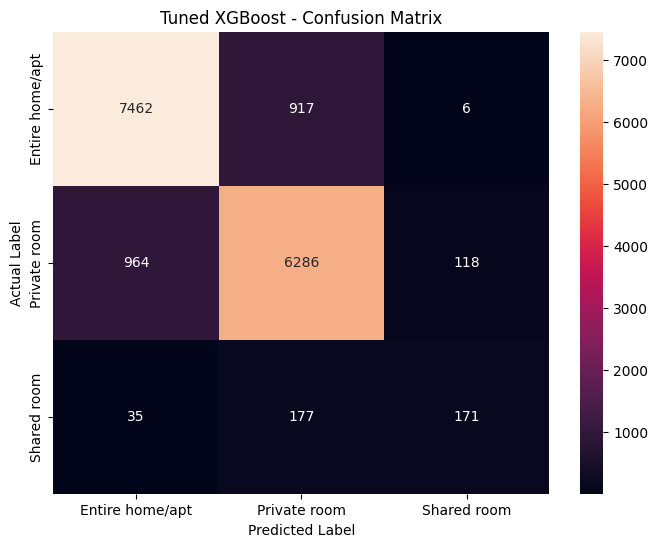

In [90]:
# EVALUATION METRICS
xgb_accuracy = accuracy_score(
    y_test_xgb,
    xgb_pred_grid
)

xgb_precision = precision_score(
    y_test_xgb,
    xgb_pred_grid,
    average='macro',
    zero_division=0
)

xgb_recall = recall_score(
    y_test_xgb,
    xgb_pred_grid,
    average='macro',
    zero_division=0
)

xgb_f1_macro = f1_score(
    y_test_xgb,
    xgb_pred_grid,
    average='macro',
    zero_division=0
)

xgb_f1_weighted = f1_score(
    y_test_xgb,
    xgb_pred_grid,
    average='weighted',
    zero_division=0
)


# FINAL RESULTS
print("=" * 60)
print("TUNED XGBOOST - EVALUATION")
print("=" * 60)

print("Validation F1 Macro:", xgb_grid.best_score_)
print("Test Accuracy:", xgb_accuracy)
print("Test Precision Macro:", xgb_precision)
print("Test Recall Macro:", xgb_recall)
print("Test F1 Macro:", xgb_f1_macro)
print("Test F1 Weighted:", xgb_f1_weighted)


# CLASSIFICATION REPORT
print("\nClassification Report:")
print(classification_report(
    y_test_xgb,
    xgb_pred_grid,
    zero_division=0
))


# CONFUSION MATRIX
xgb_cm = confusion_matrix(
    y_test_xgb,
    xgb_pred_grid
)

print("\nConfusion Matrix:")
print(xgb_cm)


# CONFUSION MATRIX PLOT
plt.figure(figsize=(8, 6))

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt='d',
    xticklabels=class_mapping.keys(),
    yticklabels=class_mapping.keys()
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Tuned XGBoost - Confusion Matrix")

plt.show()

**FINAL MODEL COMPARISON**

In [91]:
# Predictions

lr_final_pred = lr_pipeline.predict(X_test)

dt_default_pred = dt_pipeline.predict(X_test)

dt_tuned_pred = dt_grid.predict(X_test)

rf_default_pred = rf_pipeline.predict(X_test)

rf_tuned_pred = rf_grid.predict(X_test)
# XGBoost DEFAULT
xgb_default_pred = xgb_default_pipeline.predict(X_test)

# XGBoost TUNED
xgb_tuned_pred = xgb_grid.predict(X_test)

In [92]:
# METRIC FUNCTION
# ------------------------------------------------------------

def calculate_metrics(y_true, y_pred):

    return {
        "Test Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Test Precision Macro": precision_score(
            y_true,
            y_pred,
            average='macro',
            zero_division=0
        ),

        "Test Recall Macro": recall_score(
            y_true,
            y_pred,
            average='macro',
            zero_division=0
        ),

        "Test F1 Macro": f1_score(
            y_true,
            y_pred,
            average='macro',
            zero_division=0
        ),

        "Test F1 Weighted": f1_score(
            y_true,
            y_pred,
            average='weighted',
            zero_division=0
        )
    }


# ------------------------------------------------------------
# COMPARISON TABLE
# ------------------------------------------------------------

comparison_results = [

    {
        "Model": "Logistic Regression",
        "Balance Strategy": "class_weight='balanced'",
        "CV F1 Macro": lr_cv_f1,
        **calculate_metrics(y_test, lr_final_pred)
    },

    {
        "Model": "Decision Tree - Default",
        "Balance Strategy": "class_weight='balanced'",
        "CV F1 Macro": dt_cv_f1,
        **calculate_metrics(y_test, dt_default_pred)
    },

    {
        "Model": "Decision Tree - Tuned",
        "Balance Strategy": "class_weight='balanced'",
        "CV F1 Macro": dt_grid.best_score_,
        **calculate_metrics(y_test, dt_tuned_pred)
    },

    {
        "Model": "Random Forest - Default",
        "Balance Strategy": "class_weight='balanced'",
        "CV F1 Macro": rf_cv_f1,
        **calculate_metrics(y_test, rf_default_pred)
    },

    {
        "Model": "Random Forest - Tuned",
        "Balance Strategy": "class_weight='balanced'",
        "CV F1 Macro": rf_grid.best_score_,
        **calculate_metrics(y_test, rf_tuned_pred)
    },

    {
        "Model": "XGBoost - Default",
        "Balance Strategy": "Balanced sample_weight",
        "CV F1 Macro": xgb_default_cv_f1,
        **calculate_metrics(y_test_xgb, xgb_default_pred)
    },

    {
        "Model": "XGBoost - Tuned",
        "Balance Strategy": "Balanced sample_weight",
        "CV F1 Macro": xgb_grid.best_score_,
        **calculate_metrics(y_test_xgb, xgb_tuned_pred)
    }
]


comparison_df = pd.DataFrame(comparison_results)


# ------------------------------------------------------------
# SORT BY MACRO F1
# ------------------------------------------------------------

comparison_df = comparison_df.sort_values(
    by="Test F1 Macro",
    ascending=False
).reset_index(drop=True)


# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("=" * 120)
print("FINAL MODEL COMPARISON")
print("=" * 120)

print(comparison_df.round(4).to_string(index=False))

FINAL MODEL COMPARISON
                  Model        Balance Strategy  CV F1 Macro  Test Accuracy  Test Precision Macro  Test Recall Macro  Test F1 Macro  Test F1 Weighted
        XGBoost - Tuned  Balanced sample_weight       0.7496         0.8626                0.7711             0.7298         0.7476            0.8616
  Random Forest - Tuned class_weight='balanced'       0.7267         0.8576                0.8780             0.6828         0.7293            0.8545
      XGBoost - Default  Balanced sample_weight       0.7139         0.8511                0.7004             0.7528         0.7206            0.8534
Random Forest - Default class_weight='balanced'       0.7216         0.8555                0.8788             0.6696         0.7142            0.8518
  Decision Tree - Tuned class_weight='balanced'       0.6576         0.7920                0.6544             0.6693         0.6613            0.7928
Decision Tree - Default class_weight='balanced'       0.6542         0.7869  